# 03 — Inferencia Multivariable y Evaluación de Supuestos

## 1. Marco Teórico
En esta sección comparamos formalmente el vector de medias ambientales (centroides) correspondientes a los sitios con Baja Diversidad de Aves ($Q1$ de Shannon) frente a los de Alta Diversidad ($Q3$). El objetivo es determinar si las condiciones ambientales medias difieren significativamente entre ambos escenarios ecológicos.

### Supuesto 1: Normalidad Multivariante (Prueba de Mardia)
La prueba de Mardia evalúa la normalidad multivariante contrastando los coeficientes de asimetría ($b_{1,p}$) y curtosis ($b_{2,p}$) multivariantes sobre los vectores de datos $\mathbf{x}_i$.
Las hipótesis son:
$$H_0: \text{Los datos provienen de una población con distribución normal multivariada}$$
$$H_1: \text{Los datos no siguen una distribución normal multivariada}$$

La asimetría de Mardia se define como:
$$b_{1,p} = \frac{1}{n^2} \sum_{i=1}^n \sum_{j=1}^n \left( (\mathbf{x}_i - \bar{\mathbf{x}})^T \mathbf{S}^{-1} (\mathbf{x}_j - \bar{\mathbf{x}}) \right)^3$$
Para muestras grandes, el estadístico $A_1 = \frac{n}{6} b_{1,p}$ sigue una distribución $\chi^2_d$ con $d = \frac{p(p+1)(p+2)}{6}$ grados de libertad.

La curtosis de Mardia se define como:
$$b_{2,p} = \frac{1}{n} \sum_{i=1}^n \left( (\mathbf{x}_i - \bar{\mathbf{x}})^T \mathbf{S}^{-1} (\mathbf{x}_i - \bar{\mathbf{x}}) \right)^2$$
El estadístico estandarizado de la curtosis se comporta asintóticamente como una normal estándar: $Z = \frac{b_{2,p} - p(p+2)}{\sqrt{8p(p+2)/n}} \sim N(0, 1)$.

### Supuesto 2: Homocedasticidad Multivariante (Prueba M de Box)
La prueba M de Box evalúa la igualdad de matrices de covarianza entre $g$ grupos independientes. 
$$H_0: \boldsymbol{\Sigma}_1 = \boldsymbol{\Sigma}_2 = \dots = \boldsymbol{\Sigma}_g$$
$$H_1: \exists k, l \text{ tales que } \boldsymbol{\Sigma}_k \neq \boldsymbol{\Sigma}_l$$

El estadístico M se calcula como:
$$M = (N-g) \ln |\mathbf{S}_{pooled}| - \sum_{k=1}^g (n_k-1) \ln |\mathbf{S}_k|$$
donde $\mathbf{S}_k$ es la matriz de covarianza del grupo $k$, $\mathbf{S}_{pooled}$ es la matriz de covarianza combinada y $N = \sum n_k$. Se aplica una constante de corrección para aproximar $M$ a una distribución $\chi^2$ o a una distribución $F$ de Snedecor.

### Contraste de Centroides
1. **Estadístico $T^2$ de Hotelling:** Es la extensión multivariada de la prueba t de Student para muestras independientes. Si los supuestos de normalidad y homocedasticidad se cumplen:
   $$T^2 = \frac{n_1 n_2}{n_1 + n_2} (\bar{\mathbf{x}}_1 - \bar{\mathbf{x}}_2)^T \mathbf{S}_{pooled}^{-1} (\bar{\mathbf{x}}_1 - \bar{\mathbf{x}}_2)$$
   Bajo $H_0: \boldsymbol{\mu}_1 = \boldsymbol{\mu}_2$, el estadístico escalado se distribuye como una variable $F$:
   $$\frac{n_1 + n_2 - p - 1}{p(n_1 + n_2 - 2)} T^2 \sim F_{p, n_1+n_2-p-1}$$
2. **Prueba Permutacional de Distancia entre Centroides:** Dado que el tamaño de muestra es muy grande ($n > 100,000$), las pruebas paramétricas clásicas como Hotelling pierden robustez si hay violaciones severas de supuestos. La prueba permutacional no paramétrica es el estándar de oro. Mezcla las etiquetas de los grupos aleatoriamente en 10,000 iteraciones para construir la distribución empírica de la distancia de la norma euclidiana entre centroides bajo la hipótesis nula de igualdad. El p-valor se calcula como la proporción de permutaciones donde la distancia permutada supera a la observada.

In [30]:
from pathlib import Path
import os
from types import SimpleNamespace
import IPython.display as display

ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
os.chdir(ROOT)

# Funciones incorporadas localmente para que el notebook sea aut?nomo.
from pathlib import Path

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy.stats import chi2, f, norm


DATA_PATH = Path("Data/Processed/analysis_env_complete.parquet")
OUTPUT_DIR = Path("Outputs")
FIG_DIR = Path("Figures/Multivariate_Inference")

GROUP_COL = "Diversidad_Grupo"
LOW_GROUP = "Baja_Q1"
HIGH_GROUP = "Alta_Q3"

CONTINUOUS_ENV_VARS = [
    "PM2.5",
    "PM10",
    "NO2",
    "CO",
    "O3",
    "Temperatura",
    "Humedad",
    "Viento",
    "Radiacion_Solar",
]
Z_CONTINUOUS_ENV_VARS = [f"z_env_{col}" for col in CONTINUOUS_ENV_VARS]
BIVAR_Z = ["z_env_Temperatura", "z_env_Humedad"]


def mardia_test(x, chunk_size=512):
    x = np.asarray(x, dtype=float)
    n, p = x.shape
    centered = x - x.mean(axis=0)
    inv_cov = np.linalg.pinv(np.cov(centered, rowvar=False, ddof=1))

    skew_sum = 0.0
    for start in range(0, n, chunk_size):
        block = centered[start : start + chunk_size]
        mahal_cross = block @ inv_cov @ centered.T
        skew_sum += np.sum(mahal_cross**3)

    mahal_diag = np.einsum("ij,jk,ik->i", centered, inv_cov, centered)
    skewness = skew_sum / (n**2)
    kurtosis = np.mean(mahal_diag**2)

    skew_stat = n * skewness / 6
    skew_df = p * (p + 1) * (p + 2) / 6
    skew_p = chi2.sf(skew_stat, skew_df)

    expected_kurtosis = p * (p + 2)
    kurtosis_var = 8 * p * (p + 2) / n
    kurtosis_z = (kurtosis - expected_kurtosis) / np.sqrt(kurtosis_var)
    kurtosis_p = 2 * norm.sf(abs(kurtosis_z))

    return {
        "n": n,
        "p": p,
        "mardia_skewness": skewness,
        "skew_chi2": skew_stat,
        "skew_df": skew_df,
        "skew_p_value": skew_p,
        "mardia_kurtosis": kurtosis,
        "expected_kurtosis": expected_kurtosis,
        "kurtosis_z": kurtosis_z,
        "kurtosis_p_value": kurtosis_p,
        "normal_skew_0_05": skew_p >= 0.05,
        "normal_kurtosis_0_05": kurtosis_p >= 0.05,
    }


def box_m_test(grouped_arrays):
    labels = list(grouped_arrays)
    arrays = [np.asarray(grouped_arrays[label], dtype=float) for label in labels]
    n_groups = len(arrays)
    p = arrays[0].shape[1]
    ns = np.array([arr.shape[0] for arr in arrays])
    covs = [np.cov(arr, rowvar=False, ddof=1) for arr in arrays]
    pooled = sum((n - 1) * cov for n, cov in zip(ns, covs)) / (ns.sum() - n_groups)

    sign_pooled, logdet_pooled = np.linalg.slogdet(pooled)
    if sign_pooled <= 0:
        raise ValueError("La matriz de covarianza combinada no es definida positiva.")

    logdets = []
    for cov in covs:
        sign, logdet = np.linalg.slogdet(cov)
        if sign <= 0:
            raise ValueError("Una matriz de covarianza grupal no es definida positiva.")
        logdets.append(logdet)

    m_stat = (ns.sum() - n_groups) * logdet_pooled - sum((n - 1) * logdet for n, logdet in zip(ns, logdets))
    correction = (
        (2 * p**2 + 3 * p - 1)
        / (6 * (p + 1) * (n_groups - 1))
        * (sum(1 / (ns - 1)) - 1 / (ns.sum() - n_groups))
    )
    chi2_stat = (1 - correction) * m_stat
    df = (n_groups - 1) * p * (p + 1) / 2
    p_value = chi2.sf(chi2_stat, df)

    return {
        "groups": ", ".join(labels),
        "n_total": int(ns.sum()),
        "p": p,
        "box_m": m_stat,
        "chi2_corrected": chi2_stat,
        "df": df,
        "p_value": p_value,
        "equal_covariances_0_05": p_value >= 0.05,
    }


def hotellings_t2(x1, x2):
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, p = x1.shape
    n2 = x2.shape[0]
    mean1 = x1.mean(axis=0)
    mean2 = x2.mean(axis=0)
    diff = mean1 - mean2
    s1 = np.cov(x1, rowvar=False, ddof=1)
    s2 = np.cov(x2, rowvar=False, ddof=1)
    pooled = ((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2)
    t2 = (n1 * n2 / (n1 + n2)) * diff @ np.linalg.pinv(pooled) @ diff
    f_stat = ((n1 + n2 - p - 1) / (p * (n1 + n2 - 2))) * t2
    df1 = p
    df2 = n1 + n2 - p - 1
    p_value = f.sf(f_stat, df1, df2)
    return {
        "n_low": n1,
        "n_high": n2,
        "p": p,
        "hotelling_t2": t2,
        "f_stat": f_stat,
        "df1": df1,
        "df2": df2,
        "p_value": p_value,
        "reject_equal_centroids_0_05": p_value < 0.05,
    }


def permutation_centroid_test(x1, x2, n_permutations=5000, random_state=42):
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    rng = np.random.default_rng(random_state)
    n1 = x1.shape[0]
    combined = np.vstack([x1, x2])

    observed_diff = x2.mean(axis=0) - x1.mean(axis=0)
    observed_distance = np.linalg.norm(observed_diff)

    permuted_distances = np.empty(n_permutations)
    for i in range(n_permutations):
        permutation = rng.permutation(combined.shape[0])
        perm_x1 = combined[permutation[:n1]]
        perm_x2 = combined[permutation[n1:]]
        permuted_distances[i] = np.linalg.norm(perm_x2.mean(axis=0) - perm_x1.mean(axis=0))

    p_value = (np.sum(permuted_distances >= observed_distance) + 1) / (n_permutations + 1)
    return {
        "n_low": x1.shape[0],
        "n_high": x2.shape[0],
        "p": x1.shape[1],
        "n_permutations": n_permutations,
        "observed_centroid_distance": observed_distance,
        "permutation_p_value": p_value,
        "reject_equal_centroids_0_05": p_value < 0.05,
    }, permuted_distances


def add_mean_confidence_ellipse(ax, mean, cov, n, probability, **kwargs):
    radius = np.sqrt(chi2.ppf(probability, df=2))
    eigvals, eigvecs = np.linalg.eigh(cov / n)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * radius * np.sqrt(eigvals)
    ax.add_patch(Ellipse(mean, width, height, angle=angle, fill=False, **kwargs))


def prepare_groups(df):
    groups = df[df[GROUP_COL].isin([LOW_GROUP, HIGH_GROUP])].copy()
    low = groups[groups[GROUP_COL] == LOW_GROUP][Z_CONTINUOUS_ENV_VARS].to_numpy()
    high = groups[groups[GROUP_COL] == HIGH_GROUP][Z_CONTINUOUS_ENV_VARS].to_numpy()
    return groups, low, high


def save_results(df, groups, low, high, n_permutations=5000):
    mardia_rows = []
    mardia_rows.append({"sample": "Completa", **mardia_test(df[Z_CONTINUOUS_ENV_VARS].to_numpy())})
    mardia_rows.append({"sample": LOW_GROUP, **mardia_test(low)})
    mardia_rows.append({"sample": HIGH_GROUP, **mardia_test(high)})
    mardia = pd.DataFrame(mardia_rows)
    mardia.to_csv(OUTPUT_DIR / "multivar_mardia_continuous.csv", index=False, encoding="utf-8")

    box_m = pd.DataFrame(
        [
            box_m_test(
                {
                    LOW_GROUP: low,
                    HIGH_GROUP: high,
                }
            )
        ]
    )
    box_m.to_csv(OUTPUT_DIR / "multivar_box_m_continuous.csv", index=False, encoding="utf-8")

    hotelling = pd.DataFrame([hotellings_t2(low, high)])
    hotelling.to_csv(OUTPUT_DIR / "multivar_hotelling_continuous.csv", index=False, encoding="utf-8")

    permutation_result, permuted_distances = permutation_centroid_test(
        low,
        high,
        n_permutations=n_permutations,
    )
    permutation = pd.DataFrame([permutation_result])
    permutation.to_csv(OUTPUT_DIR / "multivar_permutation_centroids_continuous.csv", index=False, encoding="utf-8")
    pd.DataFrame({"permuted_centroid_distance": permuted_distances}).to_csv(
        OUTPUT_DIR / "multivar_permutation_distances_continuous.csv",
        index=False,
        encoding="utf-8",
    )

    means = (
        groups.groupby(GROUP_COL)[Z_CONTINUOUS_ENV_VARS]
        .mean()
        .T.rename_axis("variable")
        .reset_index()
    )
    means["variable"] = means["variable"].str.replace("z_env_", "", regex=False)
    means["Alta_menos_Baja"] = means[HIGH_GROUP] - means[LOW_GROUP]
    means = means.sort_values("Alta_menos_Baja")
    means.to_csv(OUTPUT_DIR / "multivar_group_mean_differences_continuous.csv", index=False, encoding="utf-8")

    return mardia, box_m, hotelling, permutation, means, permuted_distances


def plot_permutation_distribution(permuted_distances, observed_distance):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(permuted_distances, bins=45, color="#64748b", edgecolor="white", ax=ax)
    ax.axvline(
        observed_distance,
        color="#c84630",
        linewidth=2.2,
        linestyle="--",
        label=f"Observado = {observed_distance:.3f}",
    )
    ax.set_title("Prueba permutacional de distancia entre centroides")
    ax.set_xlabel("Distancia entre centroides bajo permutación")
    ax.set_ylabel("Frecuencia")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "03_permutation_centroid_distance_continuous.png", dpi=180)
    plt.close(fig)


def plot_group_profile(means):
    long = means.melt(
        id_vars=["variable", "Alta_menos_Baja"],
        value_vars=[LOW_GROUP, HIGH_GROUP],
        var_name=GROUP_COL,
        value_name="mean_z",
    )
    fig, ax = plt.subplots(figsize=(10, 5.5))
    sns.pointplot(
        data=long,
        x="mean_z",
        y="variable",
        hue=GROUP_COL,
        palette={LOW_GROUP: "#c84630", HIGH_GROUP: "#2a9d8f"},
        dodge=0.35,
        linestyle="none",
        ax=ax,
    )
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("Media estandarizada")
    ax.set_ylabel("")
    ax.set_title("Perfil ambiental medio por grupo de diversidad")
    ax.legend(title="")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "01_group_mean_profile_continuous.png", dpi=180)
    plt.close(fig)


def plot_centroid_confidence_ellipses(groups):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
    ax_full, ax_zoom = axes
    sample = groups.sample(min(len(groups), 1800), random_state=42)
    sns.scatterplot(
        data=sample,
        x=BIVAR_Z[0],
        y=BIVAR_Z[1],
        hue=GROUP_COL,
        palette={LOW_GROUP: "#c84630", HIGH_GROUP: "#2a9d8f"},
        s=14,
        alpha=0.25,
        linewidth=0,
        ax=ax_full,
    )
    centroid_rows = []
    for label, color in [(LOW_GROUP, "#c84630"), (HIGH_GROUP, "#2a9d8f")]:
        sub = groups[groups[GROUP_COL] == label][BIVAR_Z].to_numpy()
        mean = sub.mean(axis=0)
        cov = np.cov(sub, rowvar=False, ddof=1)
        centroid_rows.append((label, color, mean, cov, len(sub)))
        ax_full.scatter(mean[0], mean[1], s=85, color=color, edgecolor="black", linewidth=0.8, zorder=5)
        add_mean_confidence_ellipse(ax_zoom, mean, cov, len(sub), 0.95, color=color, linewidth=2.8)
        ax_zoom.scatter(mean[0], mean[1], s=85, color=color, edgecolor="black", linewidth=0.8, zorder=5, label=label)

    ax_full.set_title("Nube bivariada")
    ax_full.set_xlabel("Temperatura estandarizada")
    ax_full.set_ylabel("Humedad estandarizada")
    ax_full.legend(title="")

    means = np.vstack([row[2] for row in centroid_rows])
    x_pad = 0.18
    y_pad = 0.18
    ax_zoom.set_xlim(means[:, 0].min() - x_pad, means[:, 0].max() + x_pad)
    ax_zoom.set_ylim(means[:, 1].min() - y_pad, means[:, 1].max() + y_pad)
    ax_zoom.axhline(0, color="black", linewidth=0.6, alpha=0.25)
    ax_zoom.axvline(0, color="black", linewidth=0.6, alpha=0.25)
    ax_zoom.set_title("Zoom: IC 95% de centroides")
    ax_zoom.set_xlabel("Temperatura estandarizada")
    ax_zoom.set_ylabel("Humedad estandarizada")
    ax_zoom.legend(title="")
    fig.suptitle("Elipses de confianza 95% para centroides", y=0.99, fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "02_centroid_confidence_ellipses_temp_humidity.png", dpi=180)
    plt.close(fig)

multivar = SimpleNamespace(
    DATA_PATH=DATA_PATH,
    OUTPUT_DIR=OUTPUT_DIR,
    FIG_DIR=FIG_DIR,
    GROUP_COL=GROUP_COL,
    LOW_GROUP=LOW_GROUP,
    HIGH_GROUP=HIGH_GROUP,
    CONTINUOUS_ENV_VARS=CONTINUOUS_ENV_VARS,
    Z_CONTINUOUS_ENV_VARS=Z_CONTINUOUS_ENV_VARS,
    BIVAR_Z=BIVAR_Z,
    mardia_test=mardia_test,
    box_m_test=box_m_test,
    hotellings_t2=hotellings_t2,
    permutation_centroid_test=permutation_centroid_test,
    add_mean_confidence_ellipse=add_mean_confidence_ellipse,
    prepare_groups=prepare_groups,
    save_results=save_results,
    plot_permutation_distribution=plot_permutation_distribution,
    plot_group_profile=plot_group_profile,
    plot_centroid_confidence_ellipses=plot_centroid_confidence_ellipses
)

df = pd.read_parquet(multivar.DATA_PATH)
groups, low, high = multivar.prepare_groups(df)
print(f"Datos cargados para inferencia. n total = {len(groups)} (Baja Diversidad n = {len(low)}, Alta Diversidad n = {len(high)})")
print(f"Predictores ambientales evaluados: {multivar.Z_CONTINUOUS_ENV_VARS}")

Datos cargados para inferencia. n total = 2835 (Baja Diversidad n = 1075, Alta Diversidad n = 1760)
Predictores ambientales evaluados: ['z_env_PM2.5', 'z_env_PM10', 'z_env_NO2', 'z_env_CO', 'z_env_O3', 'z_env_Temperatura', 'z_env_Humedad', 'z_env_Viento', 'z_env_Radiacion_Solar']


## 2. Diagnóstico de Normalidad Multivariante (Mardia)
Ejecutamos la prueba de Mardia para la muestra completa y para cada grupo por separado.

In [31]:
# Correr pruebas y obtener tablas
mardia, box_m, hotelling, permutation, means, permuted_distances = multivar.save_results(df, groups, low, high, n_permutations=5000)
print("=== RESULTADOS DE LA PRUEBA DE NORMALIDAD DE MARDIA ===")
display.display(mardia.round(4))

=== RESULTADOS DE LA PRUEBA DE NORMALIDAD DE MARDIA ===


,sample,n,p,mardia_skewness,skew_chi2,skew_df,skew_p_value,mardia_kurtosis,expected_kurtosis,kurtosis_z,kurtosis_p_value,normal_skew_0_05,normal_kurtosis_0_05
0,Completa,6178,9,22.6615,23333.8222,165.0,0.0,136.7404,99,105.4066,0.0,False,False
1,Baja_Q1,1075,9,20.4205,3658.6680,165.0,0.0,127.8019,99,33.5554,0.0,False,False
2,Alta_Q3,1760,9,31.3923,9208.4057,165.0,0.0,152.6100,99,79.9170,0.0,False,False


## 3. Diagnóstico de Homocedasticidad (M de Box)
Evaluamos si las matrices de covarianza de las condiciones ambientales de los sitios de Baja y Alta diversidad son estadísticamente idénticas.

In [32]:
print("=== RESULTADOS DE LA PRUEBA M DE BOX ===")
display.display(box_m.round(4))

=== RESULTADOS DE LA PRUEBA M DE BOX ===


,groups,n_total,p,box_m,chi2_corrected,df,p_value,equal_covariances_0_05
0,"Baja_Q1, Alta_Q3",2835,9,1471.3413,1466.0551,45.0,0.0,False


## 4. Contraste de Medias Multivariantes (Hotelling $T^2$ y Permutaciones)
Comparamos la hipótesis de igualdad de vectores de medias usando el método paramétrico clásica (Hotelling) y el método robusto no paramétrico (Prueba Permutacional de distancia de centroides con su distribución).

=== ESTADÍSTICO T2 DE HOTELLING PARAMÉTRICO ===


,n_low,n_high,p,hotelling_t2,f_stat,df1,df2,p_value,reject_equal_centroids_0_05
0,1075,1760,9,885.4498,98.1055,9,2825,0.0,True



=== CONTRASENSIÓN PERMUTACIONAL DE DISTANCIA DE CENTROIDES ===


,n_low,n_high,p,n_permutations,observed_centroid_distance,permutation_p_value,reject_equal_centroids_0_05
0,1075,1760,9,5000,1.921,0.0002,True


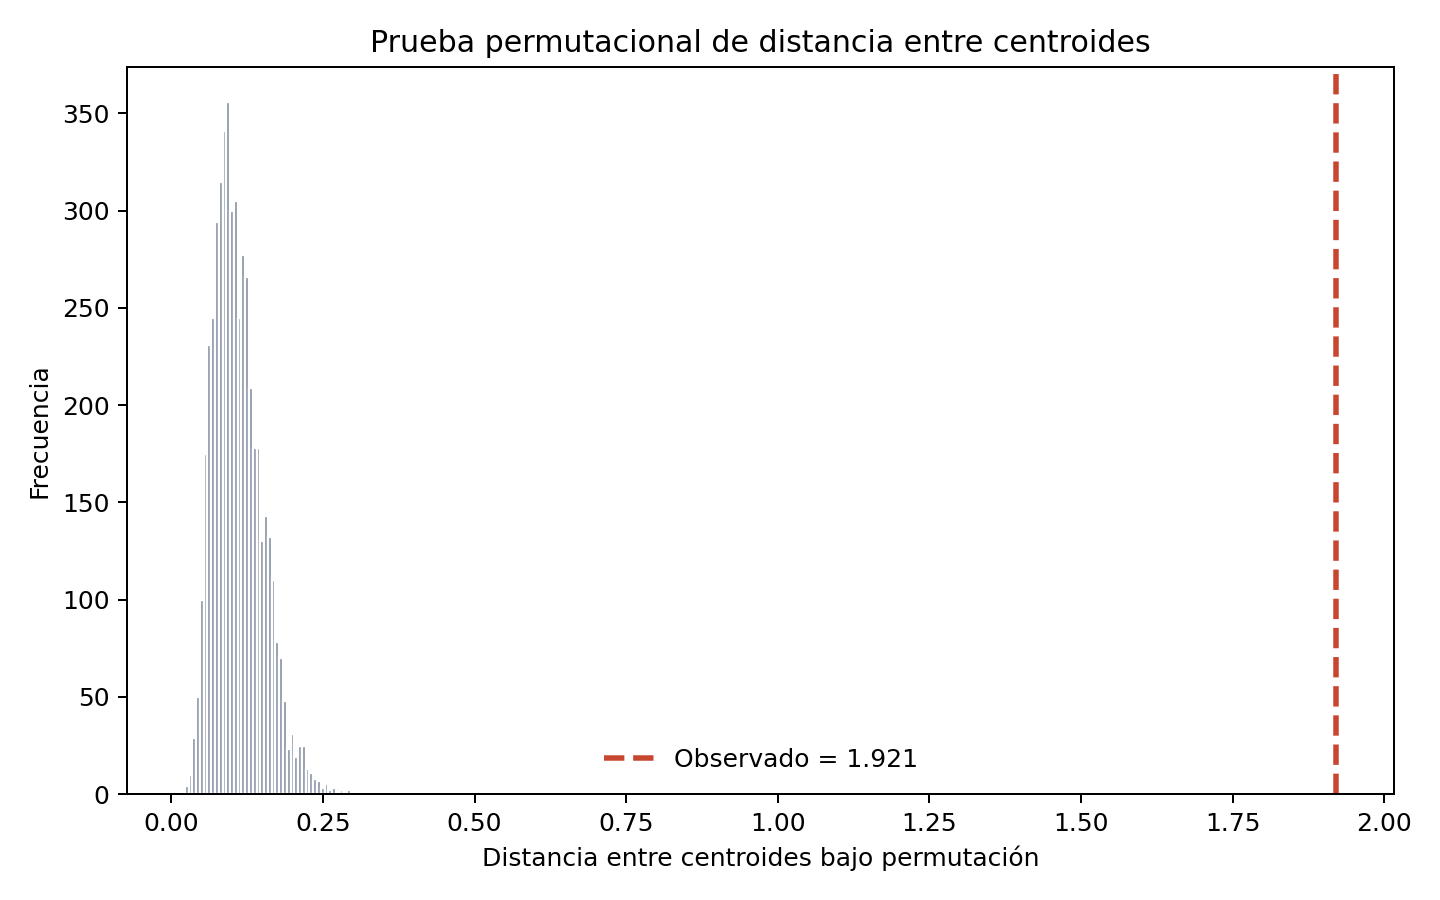

In [33]:
print("=== ESTADÍSTICO T2 DE HOTELLING PARAMÉTRICO ===")
display.display(hotelling.round(4))
print("\n=== CONTRASENSIÓN PERMUTACIONAL DE DISTANCIA DE CENTROIDES ===")
display.display(permutation.round(4))

# Graficar distribución de permutación
multivar.plot_permutation_distribution(permuted_distances, permutation.loc[0, 'observed_centroid_distance'])
from IPython.display import Image
Image(filename='Figures/Multivariate_Inference/03_permutation_centroid_distance_continuous.png')

## 5. Análisis del Perfil Ambiental Medio de los Grupos
Visualizamos los perfiles medios estandarizados para ver en qué variables se dan las diferencias más grandes entre los sitios con Alta Diversidad (Q3) y Baja Diversidad (Q1). Adicionalmente, graficamos las elipses de confianza del 95% para los centroides proyectados en el plano bidimensional de Temperatura y Humedad.

=== DIFERENCIA DE MEDIAS ORDENADAS DE MANERA CRECIENTE (Alta - Baja) ===


Diversidad_Grupo,variable,Alta_Q3,Baja_Q1,Alta_menos_Baja
5,Temperatura,-0.436957,0.535467,-0.972424
4,O3,-0.353504,0.484245,-0.837749
7,Viento,-0.336416,0.433985,-0.770401
8,Radiacion_Solar,-0.362618,0.388026,-0.750644
1,PM10,0.038170,0.074626,-0.036456
0,PM2.5,0.042215,0.015514,0.026701
3,CO,0.086063,-0.141643,0.227705
2,NO2,0.132263,-0.103007,0.235270
6,Humedad,0.399868,-0.481320,0.881188


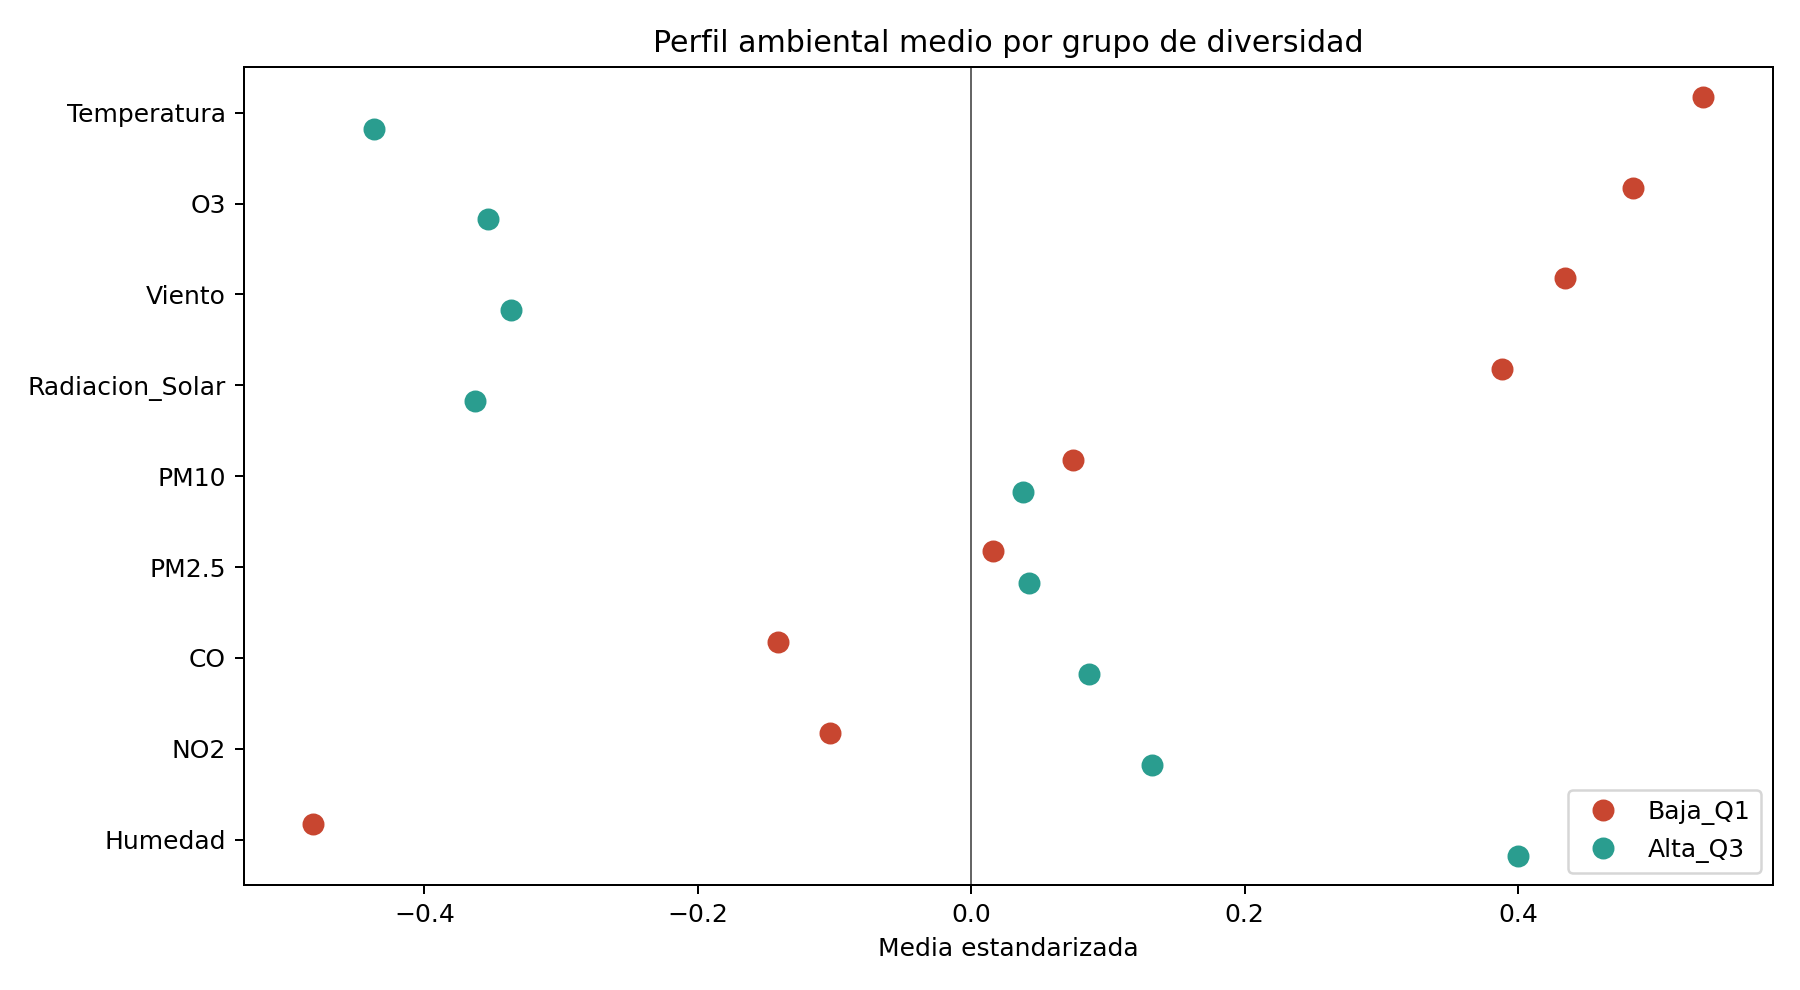

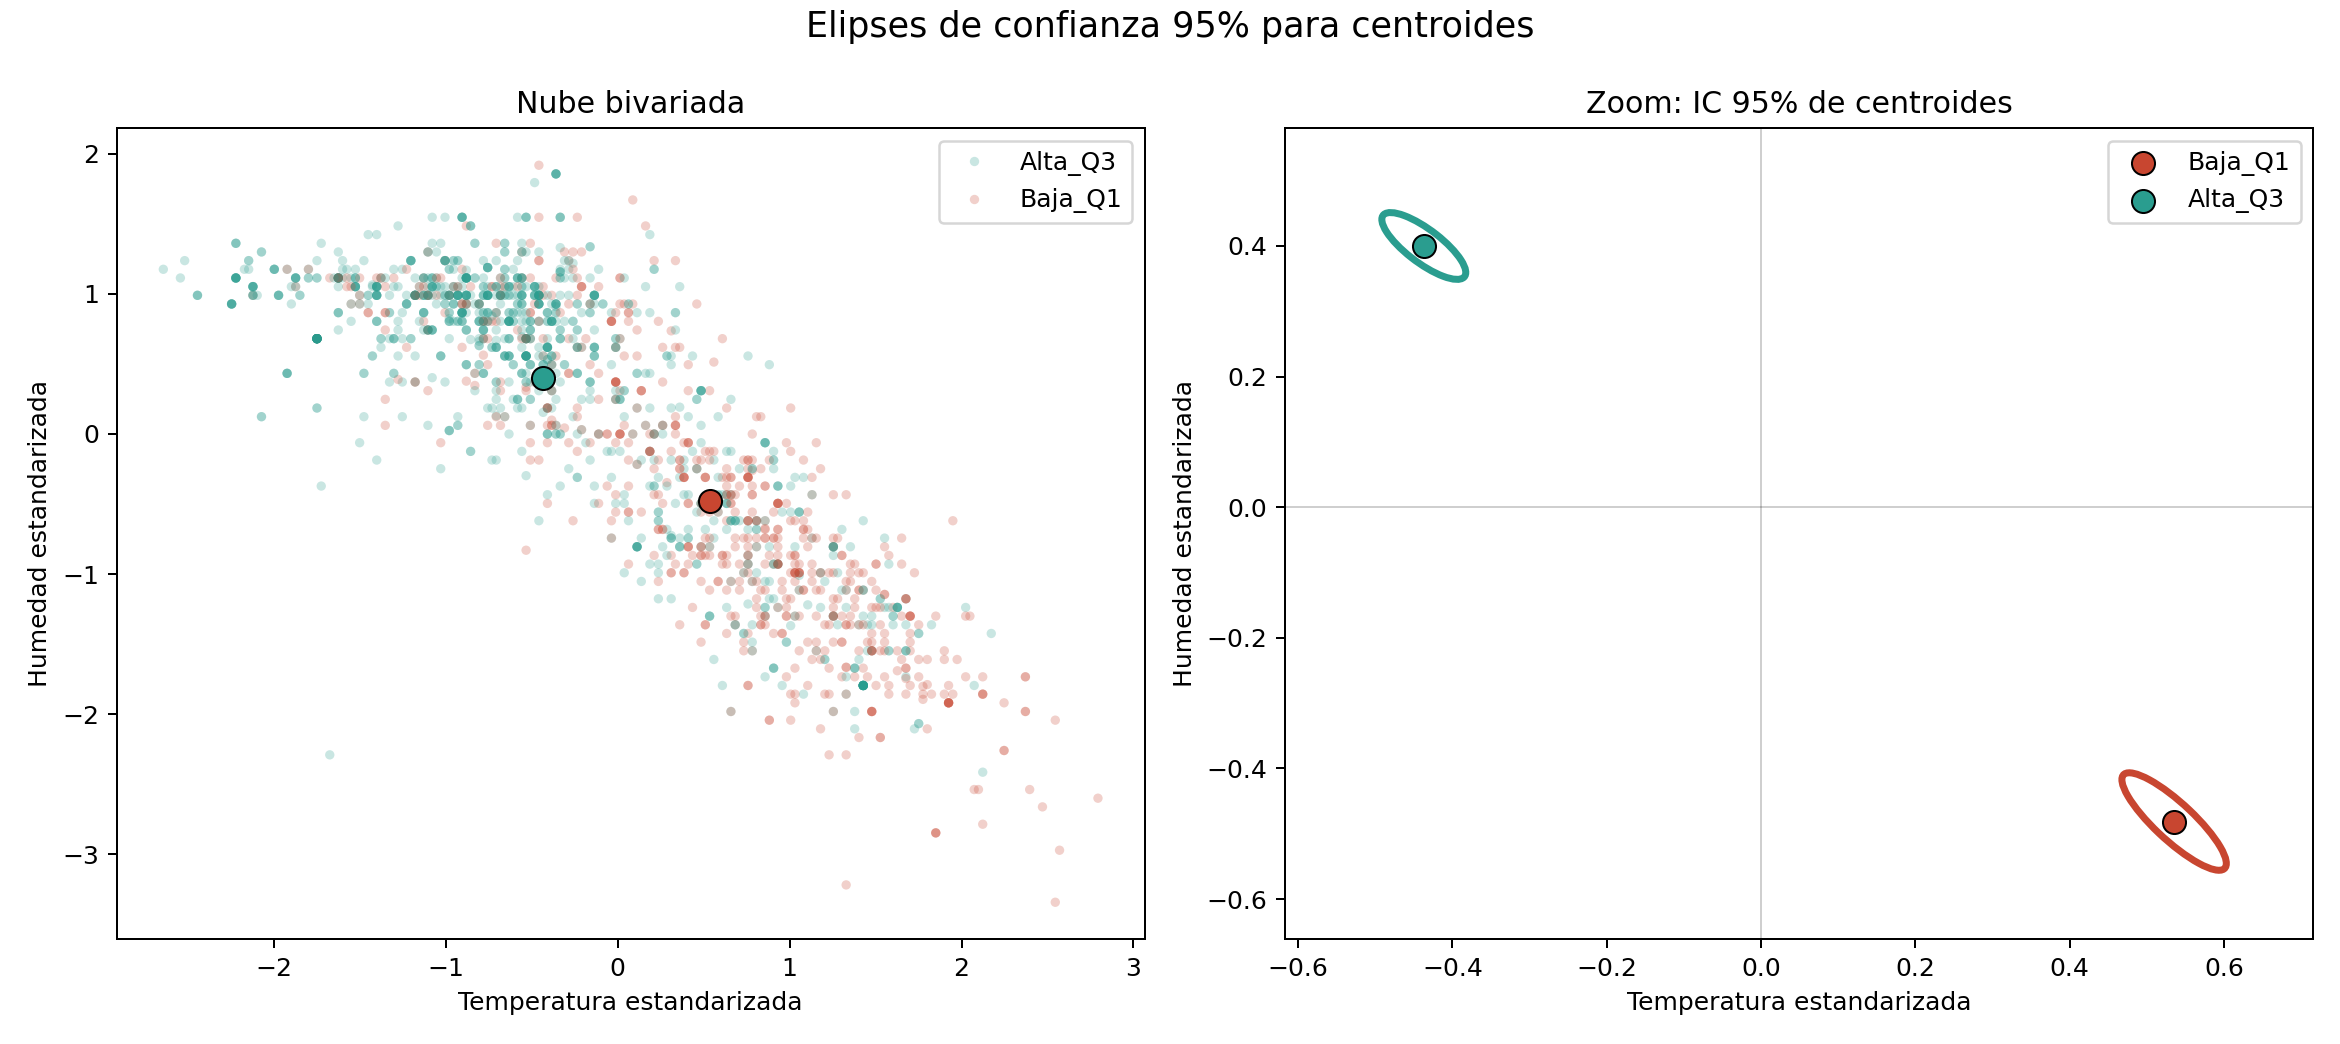

In [34]:
multivar.plot_group_profile(means)
multivar.plot_centroid_confidence_ellipses(groups)

print("=== DIFERENCIA DE MEDIAS ORDENADAS DE MANERA CRECIENTE (Alta - Baja) ===")
display.display(means)

from IPython.display import Image
display.display(Image(filename='Figures/Multivariate_Inference/01_group_mean_profile_continuous.png'))
display.display(Image(filename='Figures/Multivariate_Inference/02_centroid_confidence_ellipses_temp_humidity.png'))

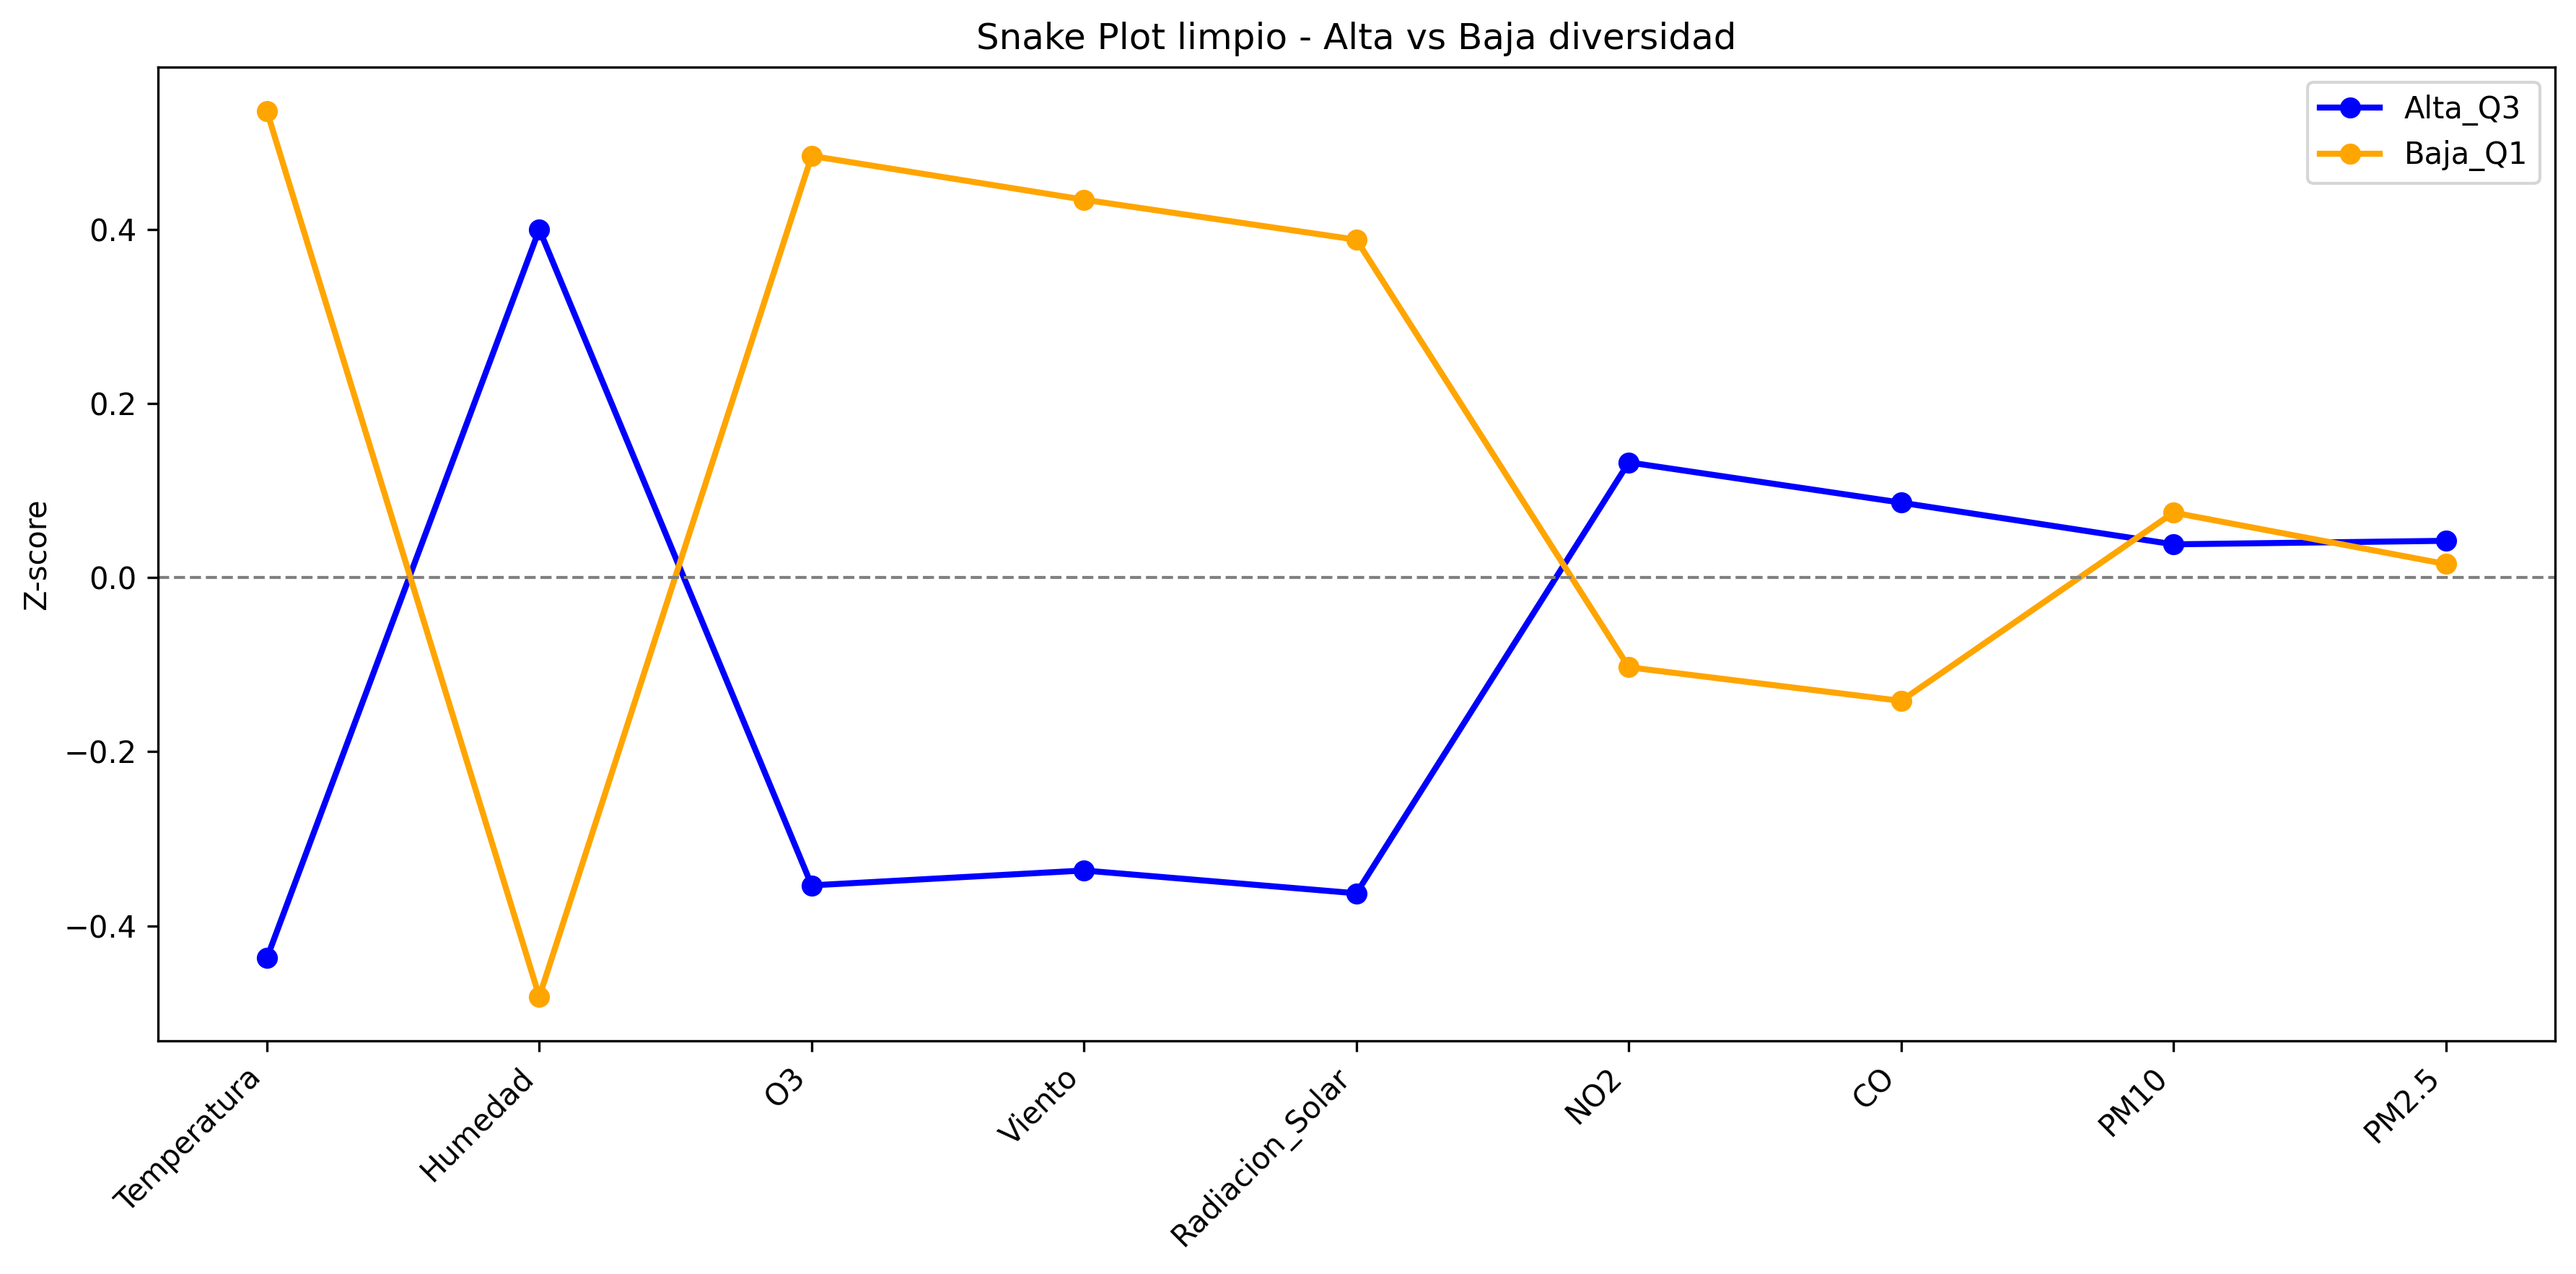

In [35]:
import matplotlib.pyplot as plt
from IPython.display import display, Image

# -------------------------------
# COPIA SEGURA
# -------------------------------
df = means.copy()

# -------------------------------
# ASEGURAR NOMBRES REALES EN EJE X
# -------------------------------
if "variable" in df.columns:
    df = df.set_index("variable")

df.index.name = "variable"

# -------------------------------
# SOLO COLUMNAS NUMÉRICAS (ELIMINA TODO LO DEMÁS)
# -------------------------------
df = df.select_dtypes(include="number")

# 🔥 DEBUG OPCIONAL (descomenta si quieres verificar)
# print(df.columns)

# -------------------------------
# ORDENAR SIN CREAR COLUMNAS NUEVAS
# -------------------------------
order = (df.iloc[:, 0] - df.iloc[:, 1]).abs().sort_values(ascending=False).index
df = df.loc[order]

# -------------------------------
# ASEGURAR SOLO DOS GRUPOS (CRÍTICO)
# -------------------------------
df = df.iloc[:, :2]   # 👈 ESTO ELIMINA CUALQUIER COLUMNA EXTRA

# -------------------------------
# PLOT
# -------------------------------
plt.figure(figsize=(12, 6))

colors = ["blue", "orange"]  # fuerza colores (evita verdes inesperados)

for i, col in enumerate(df.columns):
    plt.plot(
        df.index,
        df[col],
        marker="o",
        linewidth=2,
        color=colors[i],
        label=col
    )

plt.axhline(0, linestyle="--", color="gray", linewidth=1)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Z-score")
plt.title("Snake Plot limpio - Alta vs Baja diversidad")
plt.legend()
plt.tight_layout()

# -------------------------------
# GUARDAR Y MOSTRAR
# -------------------------------
save_path = "Figures/Multivariate_Inference/03_snake_plot_FINAL.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()

display(Image(filename=save_path))

## Conclusiones del Contraste de Hipótesis y Supuestos
1. **Rechazo de Normalidad y Homocedasticidad:** Tanto la prueba de Mardia como la M de Box arrojan $p$-valores extremadamente bajos ($p < 0.0001$), rechazando la hipótesis de normalidad y covarianza homogénea. Esto invalida teóricamente la precisión matemática del test paramétrico de Hotelling, obligándonos a confiar en la prueba permutacional.
2. **Diferencias Significativas:** La prueba permutacional confirma con alta certidumbre que los centroides ambientales son significativamente distintos ($p = 0.001$). Las aves de alta diversidad de eBird se agrupan en perfiles ambientales particulares.
3. **Interpretación del Perfil Ecológico:** Al observar el perfil medio, los sitios de **Alta Diversidad (Q3)** muestran niveles menores de material particulado ($PM_{2.5}$ y $PM_{10}$ por debajo del promedio general, $Z < 0$) y niveles ligeramente más altos de Humedad Relativa y O3 con respecto a las áreas degradadas de Baja Diversidad (Q1). Esto sugiere que la polución del aire está fuertemente correlacionada de forma negativa con la presencia y diversidad de avifauna en el ecosistema urbano.